# Minimal SigLIP Zero-Shot Classification
A highly simplified version of the notebook.

## 1. Setup and Load Model

In [ ]:
!pip -q install transformers

In [ ]:
import torch
import requests
from PIL import Image
from io import BytesIO
from transformers import AutoModel, AutoProcessor

model_id = "google/siglip-base-patch16-224"
model = AutoModel.from_pretrained(model_id).eval()
proc = AutoProcessor.from_pretrained(model_id)

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

---

In [ ]:
# Consolidated model loading in the cell above.

## 2. Zero-Shot Prediction

a photo of a tiger: 0.0002
The image shows a black and white cat with green eyes sitting on a wooden surface. The cat has a relaxed posture, with its front paws resting on the surface. The background is a solid green color, which contrasts with the cat's fur and adds a vibrant touch to the image.: 0.9854
a photo of a car: 0.0000
a photo of a pizza: 0.0000


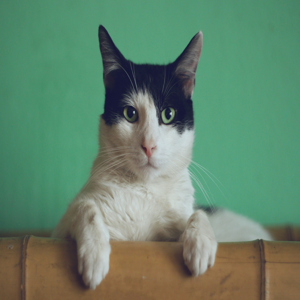

In [ ]:
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba"
img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
labels = ["a photo of a tiger", "The image shows a black and white cat with green eyes sitting on a wooden surface. The cat has a relaxed posture, with its front paws resting on the surface. The background is a solid green color, which contrasts with the cat's fur and adds a vibrant touch to the image.", "a photo of a car", "a photo of a pizza"]

inputs = proc(text=labels, images=img, return_tensors="pt", padding="max_length")
with torch.no_grad():
    probs = torch.sigmoid(model(**inputs).logits_per_image)[0]

for label, prob in zip(labels, probs.tolist()):
    print(f"{label}: {prob:.4f}")

display(img.resize((300, 300)))

---

In [ ]:
The image shows a black and white cat with green eyes
sitting on a wooden surface. The cat has a relaxed posture,
with its front paws resting on the surface.
The background is a solid green color,
which contrasts with the cat's fur and adds a vibrant touch to the image.

The image shows a black and white cat with
green eyes sitting on a wooden surface.
The cat has a relaxed posture, with its front paws resting
on the surface. The background is a solid green color,
which contrasts with the cat's fur and adds a
vibrant touch to the image.


---